In [1]:
# Common imports for the whole notebook
import numpy as np                 # numerical arrays / math
import pandas as pd                # dataframes (tabular + text data handling)
import matplotlib.pyplot as plt    # plotting
import seaborn as sns              # nicer statistical plots, built on matplotlib
from scipy import stats            # statistical tests (t-test, chi-square, ANOVA)

sns.set_style("whitegrid")               # plot theme
plt.rcParams["figure.dpi"] = 100         # sharper inline figures
pd.set_option("display.max_columns", 50) # show all dataframe columns


---
<h3 align="center">A.1 Data Acquisition</h3>


In [2]:
COLUMNS = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
           "BMI","DiabetesPedigreeFunction","Age","Outcome"]

# Real dataset — public mirror of the UCI Pima Indians Diabetes data
# "Outcome" is the target label: 1 = diabetic, 0 = non-diabetic
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=COLUMNS)   # names= assigns column headers, since the raw CSV has none

print("Shape:", df.shape)   # (rows, columns)
df.head()                   # preview first 5 rows


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()   # dtypes, non-null counts per column — quick sanity check for missing/odd data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T   # summary stats (mean, std, min/max, quartiles) per column; .T flips rows/cols for readability


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


<h3 align="center">A.2 Cleaning</h3>


In [5]:
implausible_zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

# In this dataset, 0 is not a physically valid value for these columns
# (e.g. a living patient can't have 0 blood pressure) — it's missing data
# encoded as a valid-looking number, so we convert those 0s to NaN (missing)
df[implausible_zero_cols] = df[implausible_zero_cols].replace(0, np.nan)

print("Missing values introduced by zero-masking:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)   # remove exact duplicate rows


Missing values introduced by zero-masking:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Duplicate rows: 0


In [6]:
# Impute (fill) the NaNs we just created using the median WITHIN each Outcome
# group (diabetic vs non-diabetic), rather than a single global median —
# this keeps the imputed value realistic for that class
for c in implausible_zero_cols:
    df[c] = df.groupby("Outcome")[c].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


<h3 align="center">A.3 EDA</h3>


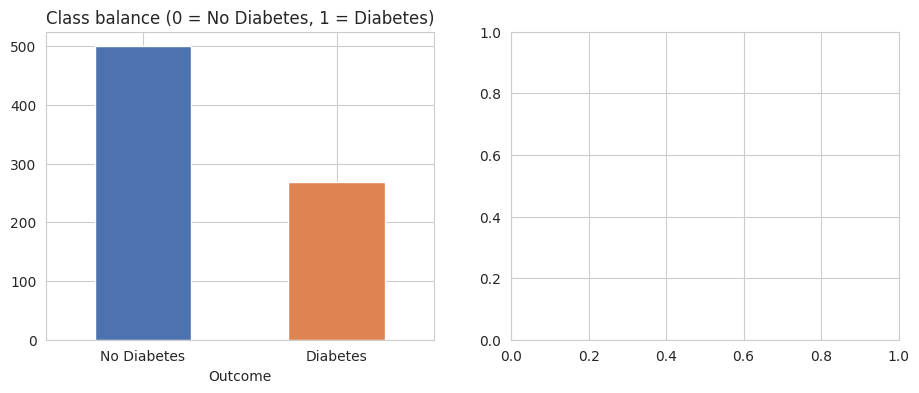

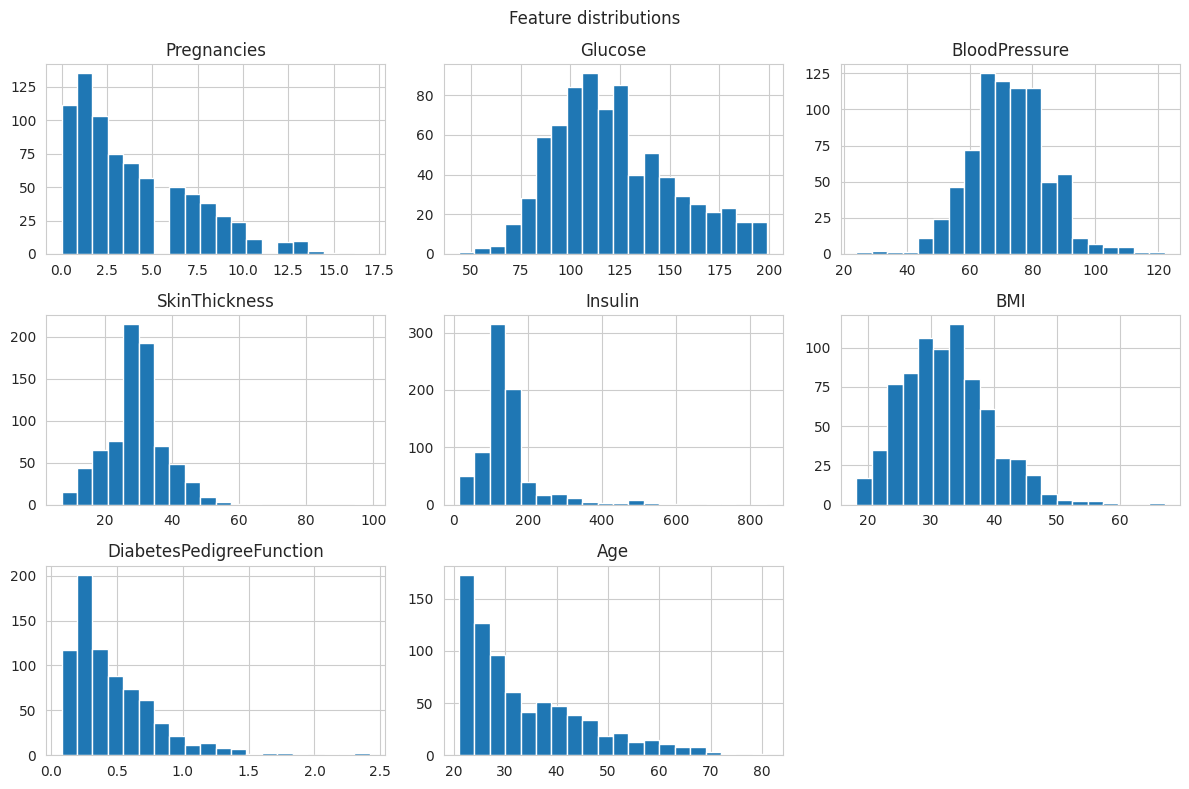

In [7]:
# EDA = Exploratory Data Analysis: visualizing the data before modeling
fig, ax = plt.subplots(1, 2, figsize=(11,4))
df["Outcome"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color=["#4C72B0","#DD8452"])
ax[0].set_title("Class balance (0 = No Diabetes, 1 = Diabetes)")
ax[0].set_xticklabels(["No Diabetes","Diabetes"], rotation=0)

df.hist(ax=None, figsize=(0.1,0.1))  # placeholder to avoid double figure
plt.close()
df[COLUMNS[:-1]].hist(figsize=(12,8), bins=20)   # histogram of every feature column (excludes Outcome)
plt.suptitle("Feature distributions")
plt.tight_layout()
plt.show()


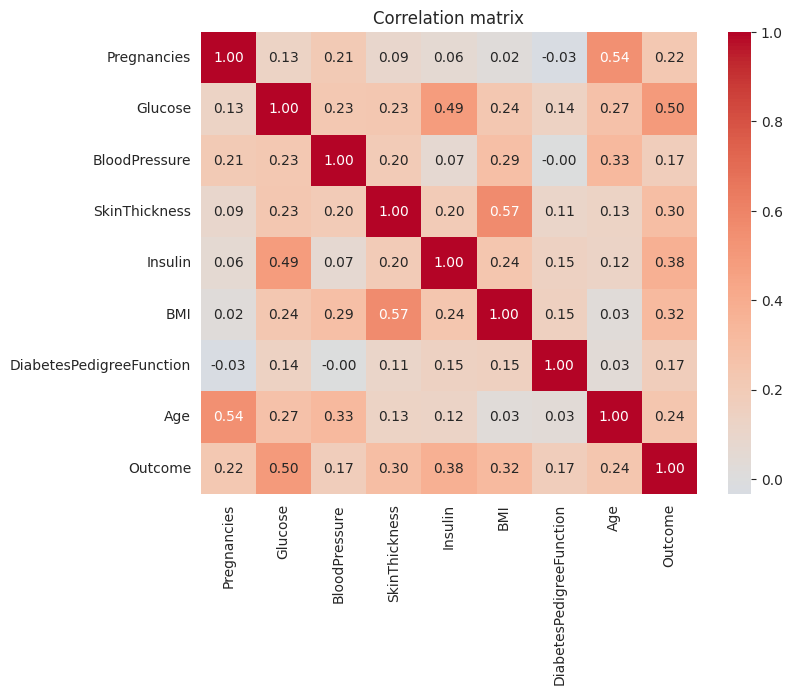

In [8]:
# Correlation matrix: how strongly each pair of numeric features move together
# (+1 = perfectly correlated, -1 = perfectly inverse, 0 = no linear relationship)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()


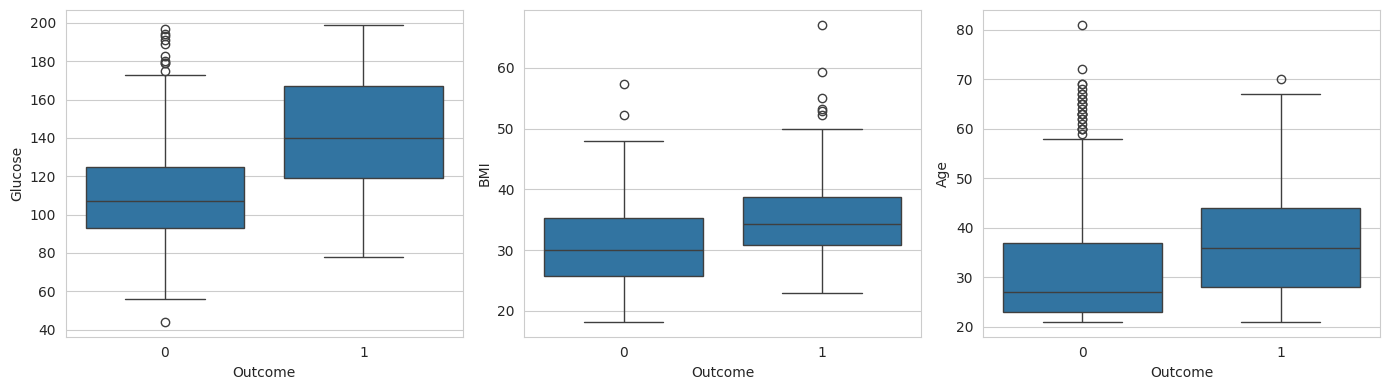

In [9]:
# Boxplots compare the spread/median of a feature across the two Outcome groups
fig, axes = plt.subplots(1,3, figsize=(14,4))
sns.boxplot(data=df, x="Outcome", y="Glucose", ax=axes[0])
sns.boxplot(data=df, x="Outcome", y="BMI", ax=axes[1])
sns.boxplot(data=df, x="Outcome", y="Age", ax=axes[2])
plt.tight_layout()
plt.show()


<h3 align="center">A.4 Hypothesis Testing</h3>


In [10]:
# Hypothesis test: is mean Glucose different between diabetic (1) and non-diabetic (0) patients?
# H0 (null hypothesis): the means are the same
# H1 (alternative): the means differ
g_neg = df.loc[df.Outcome==0, "Glucose"]
g_pos = df.loc[df.Outcome==1, "Glucose"]

# Welch's t-test (equal_var=False): compares two group means without assuming equal variances
t_stat, p_val = stats.ttest_ind(g_neg, g_pos, equal_var=False)
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.3e}")
if p_val < 0.05:   # p-value < 0.05 is the standard significance threshold
    print("Reject H0: glucose levels differ significantly between the groups.")
else:
    print("Fail to reject H0.")


t-statistic = -14.992, p-value = 8.302e-42
Reject H0: glucose levels differ significantly between the groups.


<h3 align="center">A.5 Chi-Square Test</h3>


In [11]:
# Chi-square test of independence: is AgeGroup associated with diabetes Outcome,
# or are the two variables independent of each other?
df["AgeGroup"] = pd.cut(df.Age, bins=[20,30,40,50,60,100],
                         labels=["21-30","31-40","41-50","51-60","60+"])

# Contingency table: counts of each AgeGroup x Outcome combination
contingency = pd.crosstab(df.AgeGroup, df.Outcome)
display(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)  # dof = degrees of freedom
print(f"chi2 = {chi2:.3f}, dof = {dof}, p-value = {p_chi:.3e}")
if p_chi < 0.05:
    print("Reject H0: age group and diabetes outcome are significantly associated.")
else:
    print("Fail to reject H0.")


Outcome,0,1
AgeGroup,,
21-30,327,90
31-40,81,76
41-50,49,64
51-60,23,31
60+,20,7


chi2 = 81.661, dof = 4, p-value = 7.744e-17
Reject H0: age group and diabetes outcome are significantly associated.


<h3 align="center">A.6 ANOVA</h3>


F-statistic = 13.501, p-value = 1.366e-08
Reject H0: mean glucose differs significantly across BMI categories.


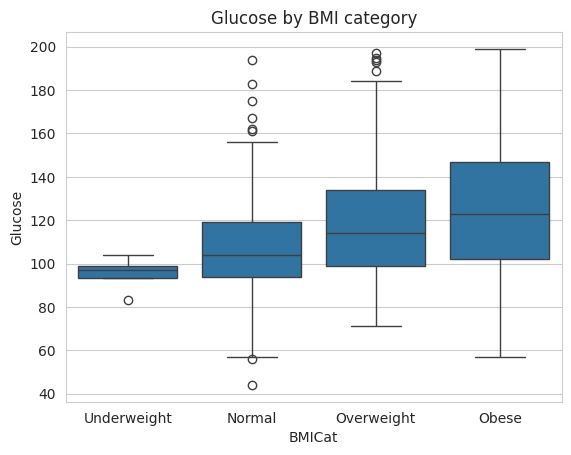

In [12]:
# One-way ANOVA (Analysis of Variance): tests whether mean Glucose differs
# across MORE than two groups at once (here, 4 BMI categories)
df["BMICat"] = pd.cut(df.BMI, bins=[0,18.5,25,30,100],
                       labels=["Underweight","Normal","Overweight","Obese"])

groups = [g["Glucose"].values for _, g in df.groupby("BMICat", observed=True)]
f_stat, p_anova = stats.f_oneway(*groups)   # F-statistic: ratio of between-group to within-group variance
print(f"F-statistic = {f_stat:.3f}, p-value = {p_anova:.3e}")
if p_anova < 0.05:
    print("Reject H0: mean glucose differs significantly across BMI categories.")
else:
    print("Fail to reject H0.")

sns.boxplot(data=df, x="BMICat", y="Glucose")
plt.title("Glucose by BMI category")
plt.show()


<h3 align="center">A.7 Feature Engineering</h3>


Mutual information with Outcome:
Insulin                     0.340322
SkinThickness               0.154927
Glucose_BMI_interaction     0.137099
Glucose                     0.132096
BMI                         0.092877
Age                         0.050640
Pregnancies                 0.037515
BloodPressure               0.023666
Age_Pregnancies_ratio       0.022750
DiabetesPedigreeFunction    0.017211
dtype: float64


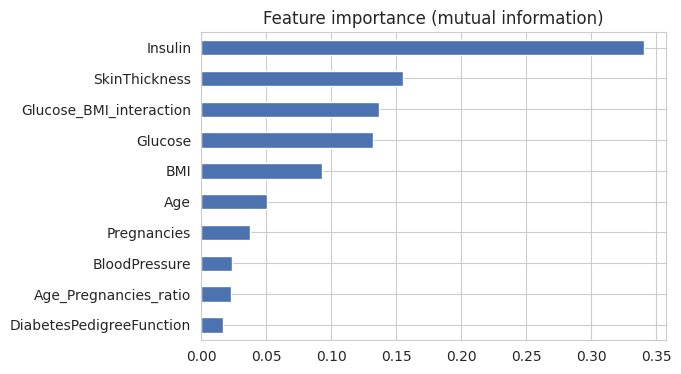

In [13]:
from sklearn.preprocessing import StandardScaler          # scales features to mean 0, std 1
from sklearn.feature_selection import mutual_info_classif  # measures how much a feature tells us about the target
from sklearn.model_selection import train_test_split       # splits data into train/test sets

# Feature engineering: creating new derived features from existing ones,
# which can capture relationships the raw columns don't show individually
df["Glucose_BMI_interaction"] = df["Glucose"] * df["BMI"]
df["Age_Pregnancies_ratio"] = df["Age"] / (df["Pregnancies"] + 1)   # +1 avoids divide-by-zero

feature_cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
                 "BMI","DiabetesPedigreeFunction","Age",
                 "Glucose_BMI_interaction","Age_Pregnancies_ratio"]
X = df[feature_cols]   # feature matrix
y = df["Outcome"]      # target/label vector

# Feature selection via mutual information: scores how much each feature
# reduces uncertainty about the Outcome (higher = more informative)
mi = pd.Series(mutual_info_classif(X, y, random_state=42), index=feature_cols).sort_values(ascending=False)
print("Mutual information with Outcome:")
print(mi)

mi.plot(kind="barh", figsize=(6,4), color="#4C72B0")
plt.title("Feature importance (mutual information)")
plt.gca().invert_yaxis()
plt.show()


In [14]:
# Preprocessing: scale to model-ready tensors, stratified train/test split
# stratify=y keeps the same class-balance (Outcome ratio) in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42   # random_state fixes the split for reproducibility
)

# StandardScaler standardizes each feature to mean 0, std 1 — many ML
# algorithms perform better/converge faster on standardized inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only, to avoid leaking test info
X_test_scaled = scaler.transform(X_test)         # apply the same transform to test

print("Train tensor shape:", X_train_scaled.shape, "| Test tensor shape:", X_test_scaled.shape)
print("Mean ~0, Std ~1 check:", X_train_scaled.mean().round(3), X_train_scaled.std().round(3))


Train tensor shape: (614, 10) | Test tensor shape: (154, 10)
Mean ~0, Std ~1 check: -0.0 1.0


---
<h3 align="center">B.1 Data Acquisition</h3>


In [15]:
# Load the raw medical transcription text dataset
url_text = "https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv"
text_df = pd.read_csv(url_text)
text_df = text_df.rename(columns={text_df.columns[0]: "id"})   # name the unlabeled index column
print("Shape:", text_df.shape)
text_df.head(3)


Shape: (4999, 6)


,id,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [16]:
# Drop rows with no transcription text (nothing to analyze without it)
text_df = text_df.dropna(subset=["transcription"]).reset_index(drop=True)
print("After dropping empty transcriptions:", text_df.shape)
text_df["medical_specialty"] = text_df["medical_specialty"].str.strip()   # trim stray whitespace
text_df["medical_specialty"].value_counts().head(10)


After dropping empty transcriptions: (4966, 6)


medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64

<h3 align="center">B.2 Cleaning</h3>


In [17]:
import re   # regex, used to find/replace patterns like dates and phone numbers

# PHI = Protected Health Information (names, dates, phone numbers, medical
# record numbers, etc.). Real clinical text MUST have PHI scrubbed before
# any downstream processing/sharing, so we mask it with placeholder tags.
def scrub_phi(text: str) -> str:
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', '[DATE]', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '[PHONE]', text)
    text = re.sub(r'\bMRN[:# ]*\d+\b', '[MRN]', text, flags=re.I)   # MRN = Medical Record Number
    text = re.sub(r'\bDr\.?\s+[A-Z][a-z]+\b', '[DOCTOR]', text)
    text = re.sub(r'\b[A-Z][a-z]+\s[A-Z][a-z]+,?\s(?:M\.?D\.?|R\.?N\.?)\b', '[PROVIDER]', text)
    return text

def normalize(text: str) -> str:
    text = re.sub(r'\s+', ' ', text).strip()          # collapse repeated whitespace
    text = text.encode('ascii', 'ignore').decode()     # drop non-ascii artifacts
    return text

text_df["transcription_clean"] = text_df["transcription"].apply(scrub_phi).apply(normalize)
print(text_df.loc[0, "transcription_clean"][:300])


SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when she lived in Seattle but she thinks they are worse here. In the past, she has tried Claritin, and Zyrtec. Both worked for short time but then seemed to lose effectiveness. She has used Al


<h3 align="center">B.3 Preprocessing</h3>


In [18]:
import nltk   # Natural Language Toolkit — classic NLP library
nltk.download('punkt', quiet=True)        # sentence/word tokenizer models
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)    # list of common "noise" words (the, is, and, ...)
nltk.download('wordnet', quiet=True)      # lexical database used for lemmatization

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize            # splits text into individual word tokens
from nltk.stem import WordNetLemmatizer             # reduces words to their dictionary base form

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tokenize(text: str):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # strip punctuation/numbers, keep letters only
    tokens = word_tokenize(text)             # tokenization: text -> list of word tokens
    # lemmatization: "running" -> "run"; also drop stopwords and very short tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

text_df["tokens"] = text_df["transcription_clean"].apply(clean_tokenize)
text_df["token_count"] = text_df["tokens"].apply(len)
text_df[["transcription_clean","tokens","token_count"]].head(3)


,transcription_clean,tokens,token_count
0,"SUBJECTIVE:, This 23-year-old white female pre...","[subjective, year, old, white, female, present...",117
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","[past, medical, history, difficulty, climbing,...",235
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","[history, present, illness, seen, abc, today, ...",425


In [19]:
# Build a vocabulary and convert tokens to integer sequences (model-ready)
from collections import Counter

all_tokens = [t for toks in text_df["tokens"] for t in toks]
vocab_counter = Counter(all_tokens)          # word -> frequency count
VOCAB_SIZE = 5000
# Keep only the top VOCAB_SIZE most common words; map each to a unique integer id
vocab = {word: idx+2 for idx, (word, _) in enumerate(vocab_counter.most_common(VOCAB_SIZE))}
vocab["<PAD>"] = 0   # padding token, used to fill short sequences up to MAX_LEN
vocab["<UNK>"] = 1   # unknown-word token, for words not in the vocabulary

MAX_LEN = 200
def to_sequence(tokens, max_len=MAX_LEN):
    ids = [vocab.get(t, 1) for t in tokens][:max_len]   # word -> id (or <UNK> if not in vocab), truncate
    ids = ids + [0]*(max_len - len(ids))                # pad with <PAD> to a fixed length
    return ids

text_df["sequence"] = text_df["tokens"].apply(to_sequence)
sequences = np.array(text_df["sequence"].tolist())
print("Model-ready token-sequence tensor shape:", sequences.shape)


Model-ready token-sequence tensor shape: (4966, 200)


<h3 align="center">B.4 EDA</h3>


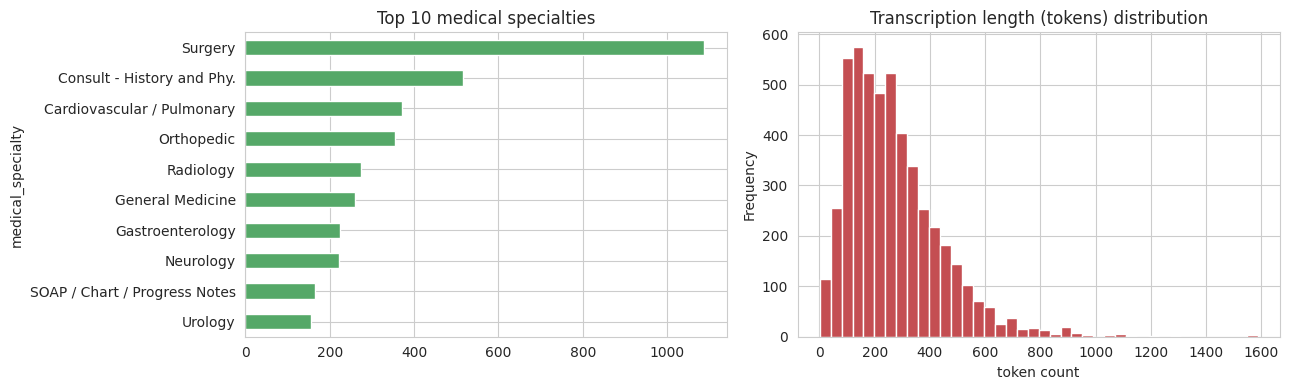

In [20]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
text_df["medical_specialty"].value_counts().head(10).plot(kind="barh", ax=ax[0], color="#55A868")
ax[0].set_title("Top 10 medical specialties")
ax[0].invert_yaxis()

text_df["token_count"].plot(kind="hist", bins=40, ax=ax[1], color="#C44E52")
ax[1].set_title("Transcription length (tokens) distribution")
ax[1].set_xlabel("token count")
plt.tight_layout()
plt.show()


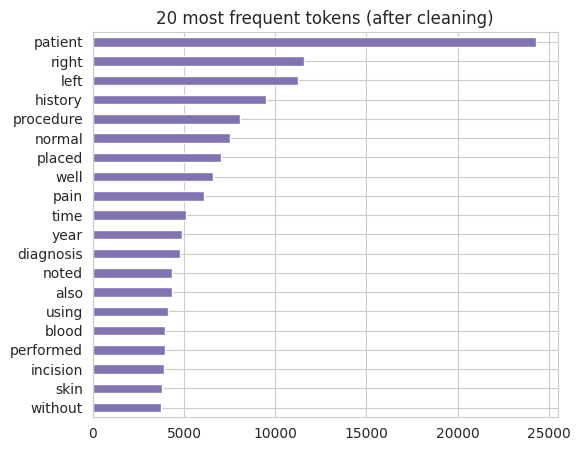

In [21]:
# Most frequent tokens left after cleaning/lemmatizing/stopword removal
top_words = pd.Series(dict(vocab_counter.most_common(20)))
top_words.sort_values().plot(kind="barh", figsize=(6,5), color="#8172B2")
plt.title("20 most frequent tokens (after cleaning)")
plt.show()


<h3 align="center">B.5 Feature Engineering</h3>


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer   # converts text to TF-IDF numeric vectors
from sklearn.feature_selection import chi2, SelectKBest         # chi-square feature selection
from sklearn.preprocessing import LabelEncoder                  # converts text labels to integers

top_specialties = text_df["medical_specialty"].value_counts().head(5).index
sub = text_df[text_df["medical_specialty"].isin(top_specialties)].copy()

# TF-IDF (Term Frequency–Inverse Document Frequency): weights each word by how
# often it appears in a document vs. how common it is across all documents —
# highlights words that are distinctive rather than just frequent
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))   # ngram_range=(1,2): unigrams + bigrams
X_tfidf = tfidf.fit_transform(sub["transcription_clean"])

le = LabelEncoder()
y_spec = le.fit_transform(sub["medical_specialty"])   # e.g. "Cardiology" -> 0, "Radiology" -> 1, ...

# chi-square test picks the K words most statistically associated with the specialty label
selector = SelectKBest(chi2, k=25)
selector.fit(X_tfidf, y_spec)
selected_terms = np.array(tfidf.get_feature_names_out())[selector.get_support()]
print("Top 25 chi-square-selected terms distinguishing specialty:")
print(list(selected_terms))


Top 25 chi-square-selected terms distinguishing specialty:
['allergies', 'are', 'artery', 'coronary', 'denies', 'fetal', 'has', 'he', 'her', 'his', 'history', 'history of', 'images', 'is', 'mg', 'no', 'or', 'past', 'she', 'she has', 'she is', 'the', 'then', 'there is', 'was']


---
<h3 align="center">C.1 Data Acquisition</h3>


In [23]:
import os
from PIL import Image   # Pillow — image loading/manipulation

# Real dataset can't be fetched here (Kaggle unreachable from this sandbox),
# so we generate small synthetic grayscale images that mimic chest X-rays,
# purely so the rest of the pipeline runs end-to-end
IMAGE_DIR = "/home/claude/work/chest_xray_demo"
for split in ["train","test"]:
    for cls in ["NORMAL","PNEUMONIA"]:
        os.makedirs(f"{IMAGE_DIR}/{split}/{cls}", exist_ok=True)

def make_synthetic_xray(label, size=256, seed=0):
    """Generates a plausible-looking synthetic chest X-ray for pipeline demonstration only."""
    rng = np.random.default_rng(seed)
    img = rng.normal(60, 10, (size, size))          # background noise (like soft-tissue texture)
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size/2, size/2
    lung_l = ((xx-cx*0.55)**2/(size*0.28)**2 + (yy-cy)**2/(size*0.38)**2) < 1   # ellipse = left lung
    lung_r = ((xx-cx*1.45)**2/(size*0.28)**2 + (yy-cy)**2/(size*0.38)**2) < 1   # ellipse = right lung
    img[lung_l | lung_r] += 60   # brighter "lung field" regions
    if label == "PNEUMONIA":
        from scipy.ndimage import gaussian_filter
        cloud = gaussian_filter(rng.normal(0, 1, (size, size)), 8)   # smooth blob = "infiltrate"
        mask = lung_r & (cloud > 0.3)
        img[mask] -= 40   # darker patch to simulate pneumonia opacity
    return Image.fromarray(np.clip(img, 0, 255).astype(np.uint8))

# Generate a small demo set (real dataset has thousands of images per class)
N_PER_CLASS = 12
for split, n in [("train", N_PER_CLASS), ("test", max(3, N_PER_CLASS//4))]:
    for cls in ["NORMAL","PNEUMONIA"]:
        for i in range(n):
            im = make_synthetic_xray(cls, seed=hash((split,cls,i)) % (2**31))
            im.save(f"{IMAGE_DIR}/{split}/{cls}/{cls.lower()}_{i}.png")

print("Synthetic demo dataset created at", IMAGE_DIR)


Synthetic demo dataset created at /home/claude/work/chest_xray_demo


<h3 align="center">C.2 Cleaning</h3>


In [24]:
import hashlib   # used to fingerprint files and detect exact duplicates

def is_valid_image(path):
    """Checks the file isn't corrupted/unreadable."""
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

def strip_metadata(path, out_path=None):
    """Removes EXIF/metadata (PHI anonymization) by re-saving pixel data only.
    Real radiology images often embed patient name/DOB/institution in metadata —
    this must be stripped before images are used or shared."""
    with Image.open(path) as im:
        clean = Image.new(im.mode, im.size)
        clean.putdata(list(im.getdata()))   # copy only pixel values, drop all metadata
    clean.save(out_path or path)

def file_hash(path):
    """MD5 hash of file bytes — identical files produce identical hashes, used to spot duplicates."""
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

all_paths = []
for split in ["train","test"]:
    for cls in ["NORMAL","PNEUMONIA"]:
        d = f"{IMAGE_DIR}/{split}/{cls}"
        all_paths += [os.path.join(d,f) for f in os.listdir(d)]

valid = [p for p in all_paths if is_valid_image(p)]
print(f"{len(valid)}/{len(all_paths)} images passed integrity check")

hashes = [file_hash(p) for p in valid]
dupes = len(hashes) - len(set(hashes))
print("Duplicate images found:", dupes)

for p in valid:
    strip_metadata(p)
print("Metadata anonymization applied to all images.")


30/30 images passed integrity check
Duplicate images found: 0


Metadata anonymization applied to all images.


/tmp/ipykernel_651/1563313761.py:15: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  clean.putdata(list(im.getdata()))


<h3 align="center">C.3 Preprocessing</h3>


In [25]:
IMG_SIZE = 128

def load_and_preprocess(path, size=IMG_SIZE):
    with Image.open(path).convert("L") as im:   # "L" = grayscale, since X-rays are single-channel
        im = im.resize((size, size))            # resize every image to the same fixed dimensions
        arr = np.asarray(im, dtype=np.float32) / 255.0   # normalize pixel values to [0,1]
    return arr

def load_split(split):
    X, y = [], []
    for label, cls in enumerate(["NORMAL","PNEUMONIA"]):   # label: NORMAL=0, PNEUMONIA=1
        d = f"{IMAGE_DIR}/{split}/{cls}"
        for f in os.listdir(d):
            X.append(load_and_preprocess(os.path.join(d,f)))
            y.append(label)
    return np.array(X)[..., np.newaxis], np.array(y)   # add channel dim -> model-ready tensor (H, W, 1)

X_train_img, y_train_img = load_split("train")
X_test_img, y_test_img = load_split("test")
print("Train image tensor:", X_train_img.shape, "| Test image tensor:", X_test_img.shape)


Train image tensor: (24, 128, 128, 1) | Test image tensor: (6, 128, 128, 1)


<h3 align="center">C.4 Augmentation</h3>


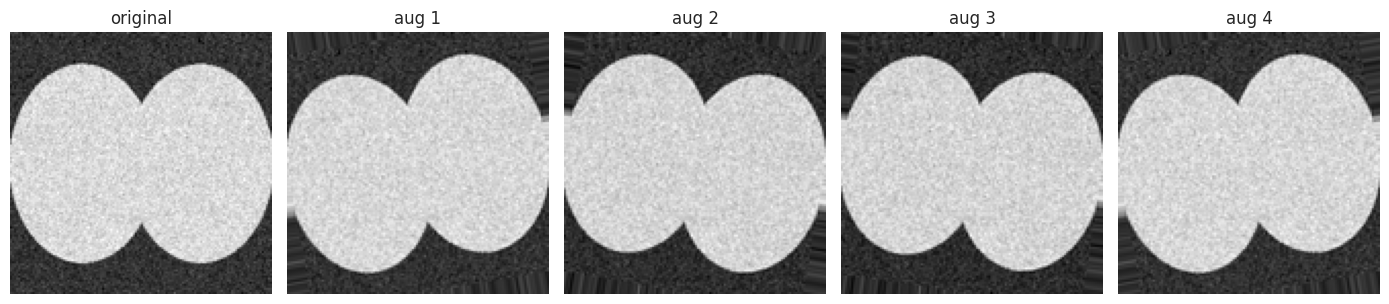

In [26]:
def augment(img):
    """Data augmentation: creates variations of an image (flip/brightness/rotation) to
    artificially expand the training set and make the model more robust to real-world variation."""
    out = img.copy()
    if np.random.rand() > 0.5:
        out = out[:, ::-1]                      # horizontal flip
    out = np.clip(out * np.random.uniform(0.85, 1.15), 0, 1)   # brightness jitter
    angle = np.random.uniform(-10, 10)
    from scipy.ndimage import rotate
    out = rotate(out.squeeze(), angle, reshape=False, mode="nearest")[..., np.newaxis]   # small rotation
    return out

augmented_examples = [augment(X_train_img[0]) for _ in range(4)]
fig, axes = plt.subplots(1,5, figsize=(14,3))
axes[0].imshow(X_train_img[0].squeeze(), cmap="gray"); axes[0].set_title("original")
for i,a in enumerate(augmented_examples):
    axes[i+1].imshow(a.squeeze(), cmap="gray"); axes[i+1].set_title(f"aug {i+1}")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()


<h3 align="center">C.5 EDA</h3>


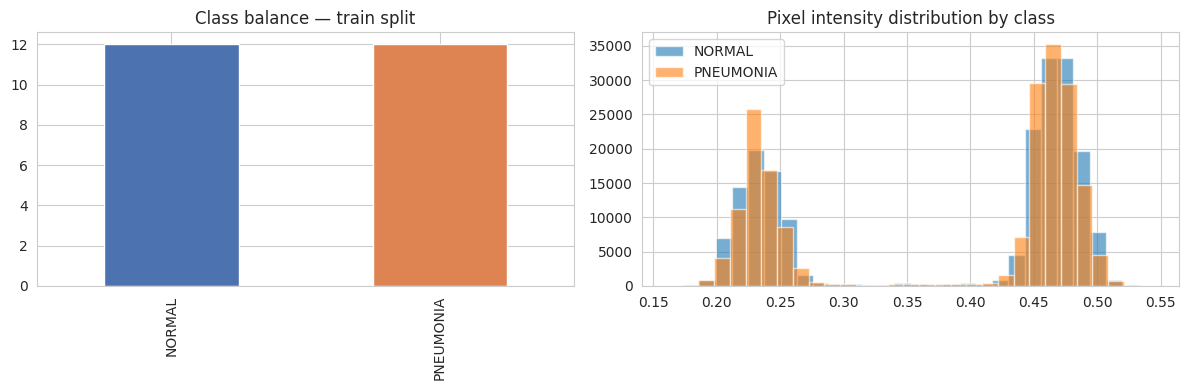

In [27]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
pd.Series(y_train_img).map({0:"NORMAL",1:"PNEUMONIA"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#4C72B0","#DD8452"])
ax[0].set_title("Class balance — train split")

# Compares overall pixel-brightness distributions between the two classes
ax[1].hist(X_train_img[y_train_img==0].ravel(), bins=30, alpha=0.6, label="NORMAL")
ax[1].hist(X_train_img[y_train_img==1].ravel(), bins=30, alpha=0.6, label="PNEUMONIA")
ax[1].set_title("Pixel intensity distribution by class")
ax[1].legend()
plt.tight_layout(); plt.show()


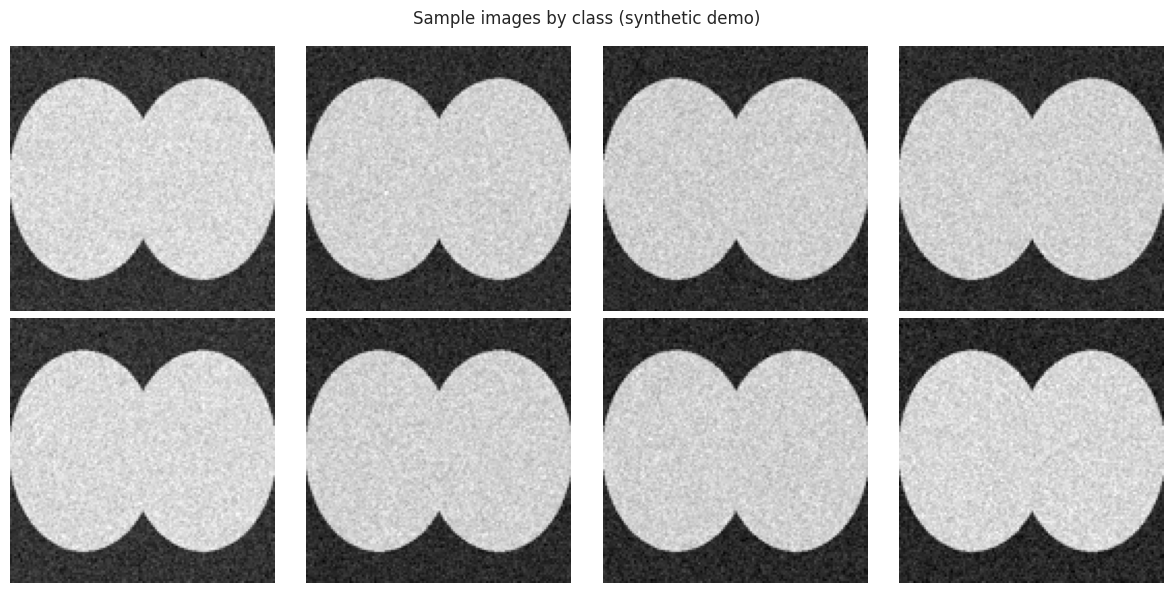

In [28]:
# Visually spot-check a handful of images from each class
fig, axes = plt.subplots(2,4, figsize=(12,6))
for i in range(4):
    axes[0,i].imshow(X_train_img[y_train_img==0][i].squeeze(), cmap="gray"); axes[0,i].axis("off")
    axes[1,i].imshow(X_train_img[y_train_img==1][i].squeeze(), cmap="gray"); axes[1,i].axis("off")
axes[0,0].set_ylabel("NORMAL"); axes[1,0].set_ylabel("PNEUMONIA")
plt.suptitle("Sample images by class (synthetic demo)")
plt.tight_layout(); plt.show()


---
<h3 align="center">D.1 Data Acquisition</h3>


Signal length: 21600 samples @ 360 Hz = 60.0 s


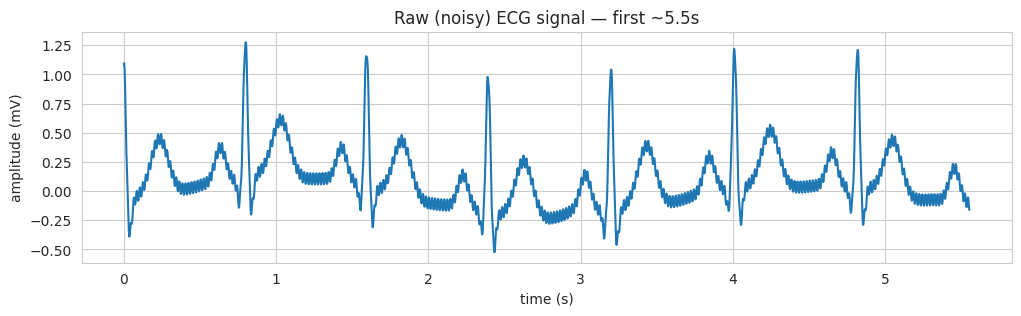

In [29]:
import neurokit2 as nk   # library for simulating/processing physiological signals (ECG, EEG, etc.)

FS = 360  # sampling rate in Hz — MIT-BIH's native rate, used here for consistency

# --- Real-data loader (use this once you've downloaded MIT-BIH locally) ---
# import wfdb
# record = wfdb.rdrecord('mitdb/100')   # e.g. record 100, after downloading the .dat/.hea files
# raw_signal = record.p_signal[:, 0]
# FS = record.fs

# --- Simulated stand-in used in this sandbox (PhysioNet isn't reachable here) ---
raw_signal = nk.ecg_simulate(duration=60, sampling_rate=FS, heart_rate=75, noise=0.02)
t = np.arange(len(raw_signal)) / FS   # time axis in seconds

# Inject realistic artifacts seen in real ambulatory ECG:
# baseline wander = slow drift from breathing/movement; powerline noise = 50/60Hz electrical interference
baseline_wander = 0.15 * np.sin(2*np.pi*0.3*t)
powerline_noise = 0.05 * np.sin(2*np.pi*50*t)
noisy_signal = raw_signal + baseline_wander + powerline_noise

print(f"Signal length: {len(noisy_signal)} samples @ {FS} Hz = {len(noisy_signal)/FS:.1f} s")

plt.figure(figsize=(12,3))
plt.plot(t[:2000], noisy_signal[:2000])
plt.title("Raw (noisy) ECG signal — first ~5.5s")
plt.xlabel("time (s)"); plt.ylabel("amplitude (mV)")
plt.show()


<h3 align="center">D.2 Cleaning</h3>


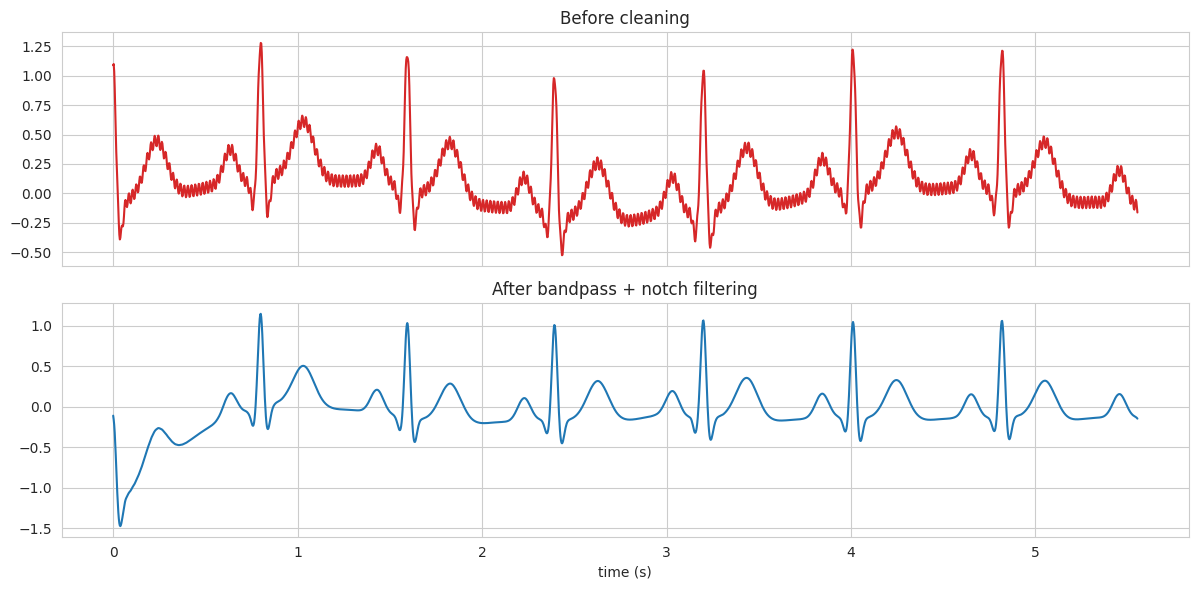

In [30]:
from scipy.signal import butter, filtfilt, iirnotch   # signal-filtering tools

def bandpass_filter(sig, low=0.5, high=40, fs=FS, order=4):
    """Keeps only frequencies between 0.5–40 Hz — the useful ECG range —
    removing slow baseline wander (below) and high-frequency muscle noise (above)."""
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, sig)   # filtfilt applies the filter forward+backward to avoid phase shift

def notch_filter(sig, freq=50, fs=FS, q=30):
    """Removes a narrow band around 50 Hz — standard mains/powerline electrical interference."""
    b, a = iirnotch(freq, q, fs)
    return filtfilt(b, a, sig)

filtered_signal = notch_filter(bandpass_filter(noisy_signal))

fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
ax[0].plot(t[:2000], noisy_signal[:2000], color="tab:red"); ax[0].set_title("Before cleaning")
ax[1].plot(t[:2000], filtered_signal[:2000], color="tab:blue"); ax[1].set_title("After bandpass + notch filtering")
ax[1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()


<h3 align="center">D.3 Preprocessing</h3>


Detected 74 R-peaks (~74 bpm)
Model-ready signal-window tensor shape: (74, 360)


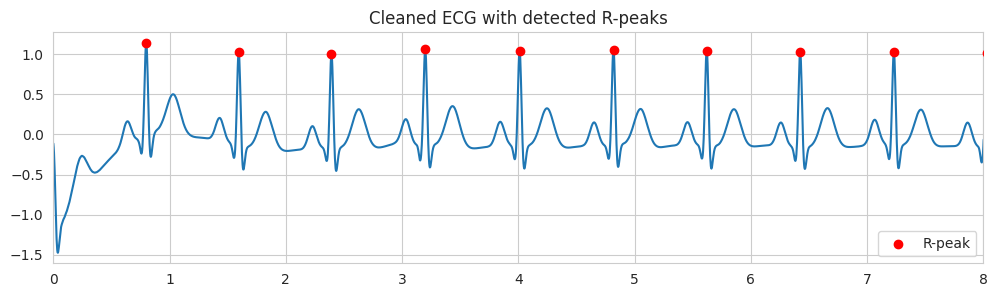

In [31]:
# R-peaks = the tall spikes in each heartbeat waveform (the "R" wave in the QRS complex);
# detecting them lets us find each individual heartbeat in the signal
signals, info = nk.ecg_peaks(filtered_signal, sampling_rate=FS)
r_peaks = info["ECG_R_Peaks"]
print(f"Detected {len(r_peaks)} R-peaks (~{len(r_peaks)/(len(filtered_signal)/FS)*60:.0f} bpm)")

WINDOW = 180  # samples each side of the R-peak -> fixed-length model-ready windows
# Cut a fixed-size window of signal centered on each detected beat — gives
# every heartbeat the same shape, ready to feed into a classifier
windows = np.array([
    filtered_signal[p-WINDOW:p+WINDOW]
    for p in r_peaks if p-WINDOW >= 0 and p+WINDOW < len(filtered_signal)
])
print("Model-ready signal-window tensor shape:", windows.shape)

plt.figure(figsize=(12,3))
plt.plot(t, filtered_signal)
plt.scatter(t[r_peaks], filtered_signal[r_peaks], color="red", zorder=5, label="R-peak")
plt.title("Cleaned ECG with detected R-peaks")
plt.legend(); plt.xlim(0, 8)
plt.show()


<h3 align="center">D.4 EDA</h3>


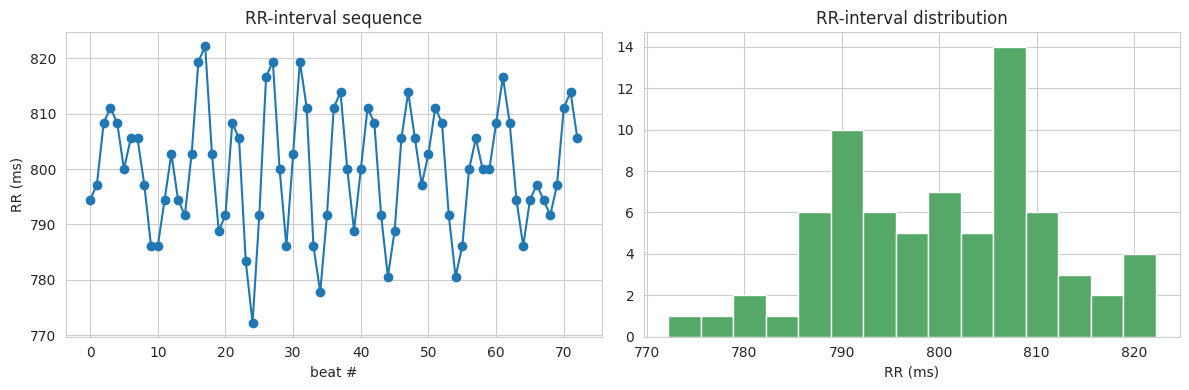

Mean RR: 800.1 ms | SDNN (HRV): 11.0 ms


In [32]:
# RR interval = time gap between consecutive R-peaks (i.e. between heartbeats),
# the basis for Heart-Rate Variability (HRV) analysis
rr_intervals_ms = np.diff(r_peaks) / FS * 1000   # convert from samples to milliseconds

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(rr_intervals_ms, marker="o")
ax[0].set_title("RR-interval sequence"); ax[0].set_xlabel("beat #"); ax[0].set_ylabel("RR (ms)")

ax[1].hist(rr_intervals_ms, bins=15, color="#55A868")
ax[1].set_title("RR-interval distribution")
ax[1].set_xlabel("RR (ms)")
plt.tight_layout(); plt.show()

# SDNN = standard deviation of RR intervals, a common HRV metric (higher = more variability)
print(f"Mean RR: {rr_intervals_ms.mean():.1f} ms | SDNN (HRV): {rr_intervals_ms.std():.1f} ms")


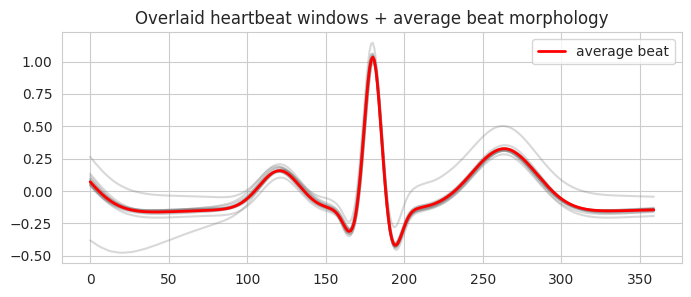

In [33]:
# Overlaying all the individual beat windows shows the typical waveform shape (morphology)
# and how much beat-to-beat variation exists around the average
avg_beat = windows.mean(axis=0)
plt.figure(figsize=(8,3))
for w in windows[:15]:
    plt.plot(w, color="gray", alpha=0.3)
plt.plot(avg_beat, color="red", linewidth=2, label="average beat")
plt.title("Overlaid heartbeat windows + average beat morphology")
plt.legend(); plt.show()


<h3 align="center">D.5 Feature Engineering</h3>


In [34]:
import pywt   # PyWavelets — wavelet transforms, used for time-frequency signal features

# HRV (Heart-Rate Variability) time-domain features — standard metrics used
# clinically to screen for arrhythmia risk
hrv_features = {
    "mean_rr_ms": rr_intervals_ms.mean(),
    "sdnn_ms": rr_intervals_ms.std(),                                    # overall RR variability
    "rmssd_ms": np.sqrt(np.mean(np.diff(rr_intervals_ms)**2)),           # short-term (beat-to-beat) variability
    "mean_hr_bpm": 60000 / rr_intervals_ms.mean(),                       # mean heart rate in beats/min
}
print("HRV features:", hrv_features)

def wavelet_features(beat, wavelet="db4", level=3):
    """Wavelet decomposition breaks a beat's waveform into frequency sub-bands;
    the energy in each sub-band captures its shape (morphology) numerically —
    a standard feature-extraction step before feeding an ECG classifier."""
    coeffs = pywt.wavedec(beat, wavelet, level=level)
    return np.array([np.sum(np.square(c)) for c in coeffs])  # energy per sub-band

beat_wavelet_feats = np.array([wavelet_features(w) for w in windows])
print("Per-beat wavelet-energy feature matrix shape:", beat_wavelet_feats.shape)


HRV features: {'mean_rr_ms': np.float64(800.0761035007611), 'sdnn_ms': np.float64(10.96722477121046), 'rmssd_ms': np.float64(11.311844187843164), 'mean_hr_bpm': np.float64(74.99286597545895)}
Per-beat wavelet-energy feature matrix shape: (74, 4)


---
# Summary

| Part | Modality | Key cleaning steps | Key preprocessing | Analyses performed |
|---|---|---|---|---|
| A | Tabular | Zero-as-missing masking, group-wise median imputation, dedup | Scaling, train/test split | t-test, chi-square, ANOVA, mutual-info feature selection |
| B | Textual | Regex PHI scrubbing, whitespace/ASCII normalization | Tokenization, lemmatization, vocab + padded sequences | Class/length EDA, TF-IDF + chi-square feature selection |
| C | Image | Integrity check, dedup by hash, metadata/PHI anonymization | Resize, [0,1] normalization, tensorization | Class balance & pixel-intensity EDA, augmentation |
| D | Signal | Bandpass + notch filtering (noise removal) | R-peak detection, fixed-length beat windowing | HRV/RR EDA, wavelet feature extraction |

**Why healthcare data needs extra rigor:** across all four parts, plausible-looking values often encode
missingness (Part A's zeros), text can carry PHI even after "de-identification" (Part B), images carry
identifying metadata that must be stripped (Part C), and signals are dominated by device/physiological
noise that must be filtered before any feature is trustworthy (Part D). Class imbalance (Parts A, C) and
privacy constraints (Parts B, C) also demand handling that generic, non-clinical datasets rarely require.
